# 🔍 EDA — Synthetic UPI Transaction Dataset
**File:** `upi_synthetic.csv` + `upi_accounts.csv`  
**Purpose:** Understand the structure, distributions, and fraud patterns in the self-generated UPI dataset before feature engineering.

---

## Cell 1 — Imports
Load all libraries needed for EDA. `matplotlib` and `seaborn` for static plots, `plotly` for interactive charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Libraries loaded')

✅ Libraries loaded


## Cell 2 — Load Datasets
Load both CSV files. `upi_synthetic.csv` contains transactions. `upi_accounts.csv` contains account metadata including which accounts are mules.

In [2]:
df = pd.read_csv('../data/raw/upi_synthetic.csv')
df_accounts = pd.read_csv('../data/raw/upi_accounts.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

print('=== TRANSACTIONS ===')
print(f'Shape         : {df.shape}  ({df.shape[0]:,} rows, {df.shape[1]} columns)')
print(f'Date range    : {df["timestamp"].min()} → {df["timestamp"].max()}')
print(f'Fraud txns    : {df["is_fraud"].sum():,}')
print(f'Fraud rate    : {df["is_fraud"].mean()*100:.2f}%')
print()
print('=== ACCOUNTS ===')
print(f'Shape         : {df_accounts.shape}')
print(f'Mule accounts : {df_accounts["is_mule"].sum()}')
print(f'Mule rate     : {df_accounts["is_mule"].mean()*100:.1f}%')
print()
print('=== TRANSACTION COLUMNS ===')
df.dtypes

=== TRANSACTIONS ===
Shape         : (50000, 9)  (50,000 rows, 9 columns)
Date range    : 2024-01-01 00:11:00 → 2024-03-30 23:58:00
Fraud txns    : 2,283
Fraud rate    : 4.57%

=== ACCOUNTS ===
Shape         : (5000, 6)
Mule accounts : 500
Mule rate     : 10.0%

=== TRANSACTION COLUMNS ===


txn_id                  object
sender_id               object
sender_vpa              object
receiver_id             object
receiver_vpa            object
amount                 float64
timestamp       datetime64[ns]
txn_type                object
is_fraud                 int64
dtype: object

## Cell 3 — Missing Values Check
Check if any columns have null values. Missing values must be handled before model training.

In [3]:
print('=== MISSING VALUES — TRANSACTIONS ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print()
print('=== MISSING VALUES — ACCOUNTS ===')
print(df_accounts.isnull().sum())
print()
if missing.sum() == 0:
    print('✅ No missing values in transactions dataset — clean to proceed!')
else:
    print(f'⚠️ Found missing values — handle before feature engineering')

=== MISSING VALUES — TRANSACTIONS ===
              Missing Count  Missing %
txn_id                    0        0.0
sender_id                 0        0.0
sender_vpa                0        0.0
receiver_id               0        0.0
receiver_vpa              0        0.0
amount                    0        0.0
timestamp                 0        0.0
txn_type                  0        0.0
is_fraud                  0        0.0

=== MISSING VALUES — ACCOUNTS ===
account_id          0
vpa                 0
name                0
bank                0
account_age_days    0
is_mule             0
dtype: int64

✅ No missing values in transactions dataset — clean to proceed!


## Cell 4 — Basic Statistics
Descriptive statistics for numerical columns. Shows min, max, mean, std for amount and other fields.

In [4]:
print('=== DESCRIPTIVE STATISTICS ===')
df[['amount', 'is_fraud']].describe().round(2)

=== DESCRIPTIVE STATISTICS ===


,amount,is_fraud
count,50000.00,50000.00
mean,1360.75,0.05
std,2338.55,0.21
min,3.81,0.00
25%,297.35,0.00
50%,664.68,0.00
75%,1492.56,0.00
max,100000.00,1.00


## Cell 5 — Fraud vs Legit Class Distribution
Shows how many transactions are fraud vs legit. Class imbalance is expected and important to understand before training.

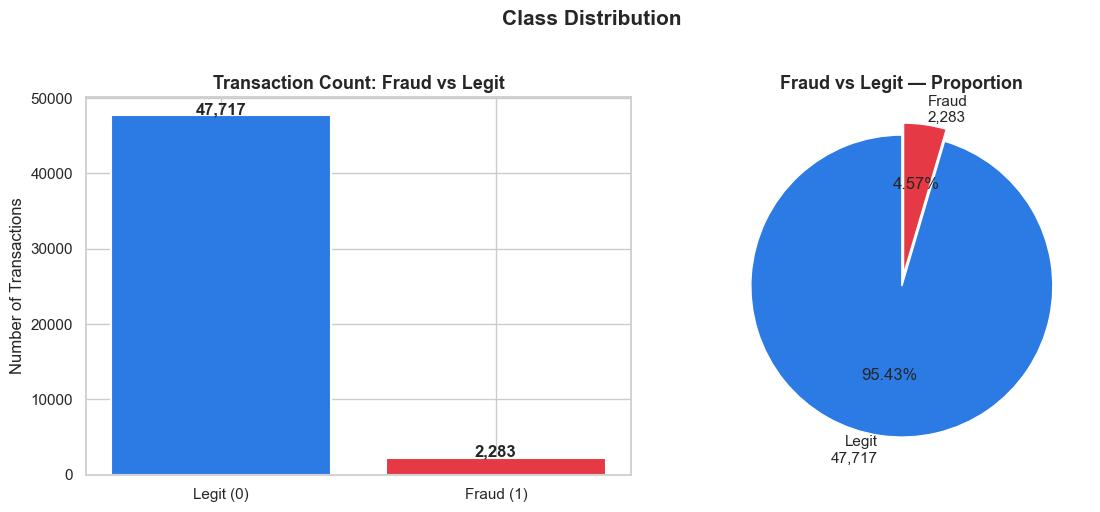

Class imbalance ratio — Legit:Fraud = 20:1
This means for every 1 fraud, there are ~20 legit transactions
XGBoost will use scale_pos_weight=20 to handle this


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['is_fraud'].value_counts()
labels = ['Legit (0)', 'Fraud (1)']
colors = ['#2C7BE5', '#E63946']
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Count: Fraud vs Legit', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=[f'Legit\n{counts[0]:,}', f'Fraud\n{counts[1]:,}'],
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.08)
)
axes[1].set_title('Fraud vs Legit — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Class imbalance ratio — Legit:Fraud = {counts[0]//counts[1]}:1')
print(f'This means for every 1 fraud, there are ~{counts[0]//counts[1]} legit transactions')
print(f'XGBoost will use scale_pos_weight={counts[0]//counts[1]} to handle this')

## Cell 6 — Amount Distribution: Fraud vs Legit
Are fraudulent transactions higher or lower in amount than legit ones? This is a key insight.

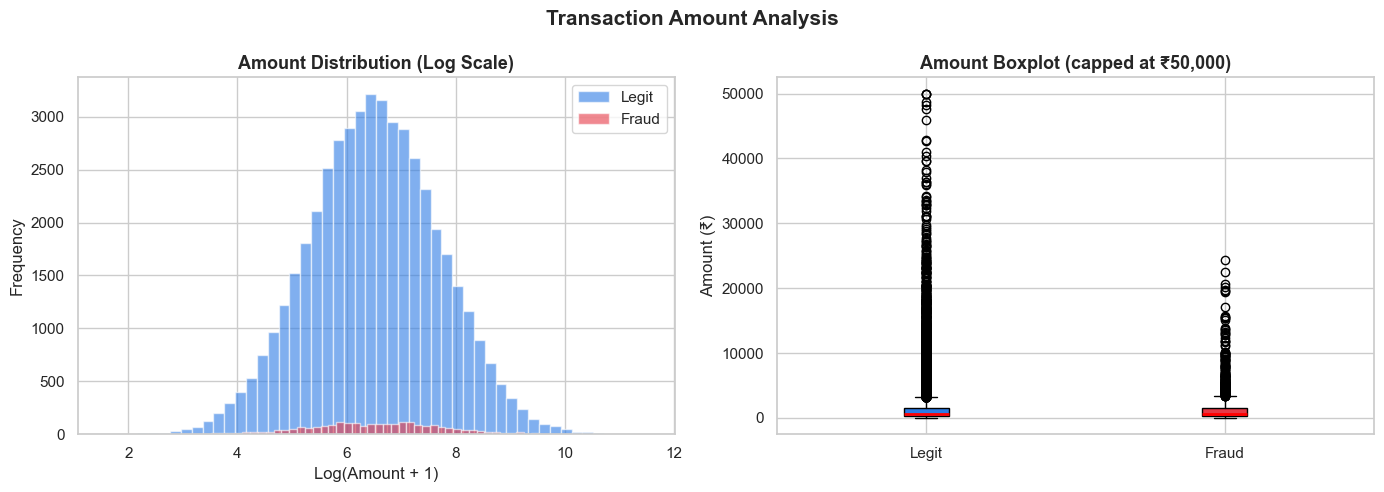

Legit  — Mean: ₹1,360  |  Median: ₹664  |  Max: ₹100,000
Fraud  — Mean: ₹1,379  |  Median: ₹683  |  Max: ₹24,298


In [6]:
fraud = df[df['is_fraud'] == 1]['amount']
legit = df[df['is_fraud'] == 0]['amount']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — log scale for better visibility
axes[0].hist(np.log1p(legit), bins=50, alpha=0.6, color='#2C7BE5', label='Legit')
axes[0].hist(np.log1p(fraud), bins=50, alpha=0.6, color='#E63946', label='Fraud')
axes[0].set_xlabel('Log(Amount + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Amount Distribution (Log Scale)', fontsize=13, fontweight='bold')
axes[0].legend()

# Boxplot
data_box = [
    df[df['is_fraud']==0]['amount'].clip(upper=50000),
    df[df['is_fraud']==1]['amount'].clip(upper=50000)
]
bp = axes[1].boxplot(data_box, patch_artist=True,
                      labels=['Legit', 'Fraud'],
                      boxprops=dict(facecolor='#E8F0FA'),
                      medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#2C7BE5')
bp['boxes'][1].set_facecolor('#E63946')
axes[1].set_title('Amount Boxplot (capped at ₹50,000)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount (₹)')

plt.suptitle('Transaction Amount Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Legit  — Mean: ₹{legit.mean():,.0f}  |  Median: ₹{legit.median():,.0f}  |  Max: ₹{legit.max():,.0f}')
print(f'Fraud  — Mean: ₹{fraud.mean():,.0f}  |  Median: ₹{fraud.median():,.0f}  |  Max: ₹{fraud.max():,.0f}')

## Cell 7 — Transaction Type Breakdown
How are P2P, MERCHANT, and BILL transactions distributed? Which types have the most fraud?

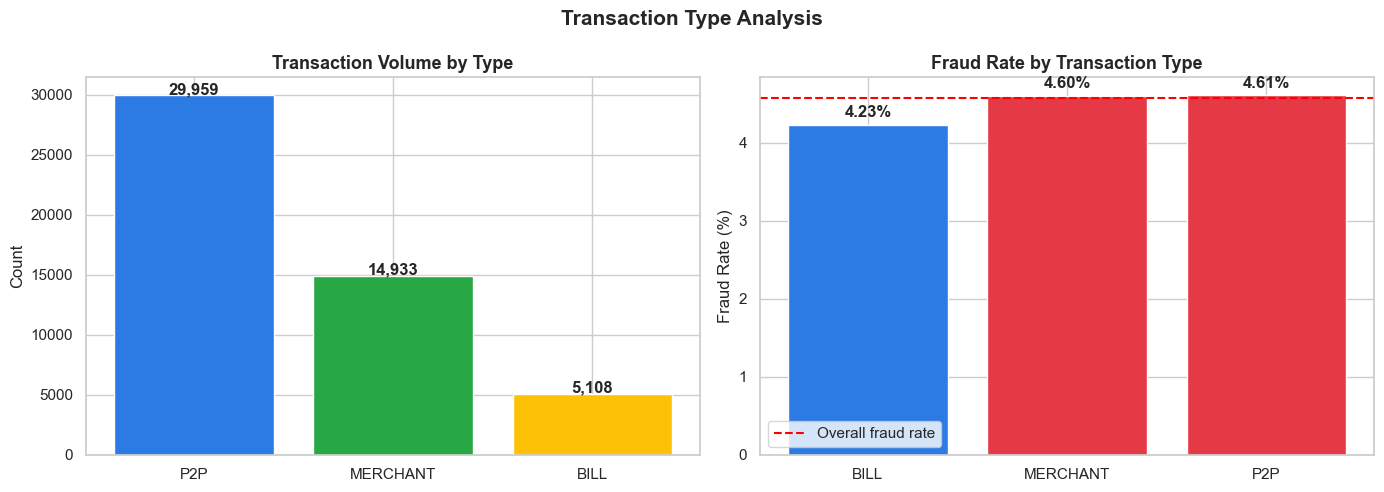

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall transaction type counts
type_counts = df['txn_type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#2C7BE5','#28A745','#FFC107'], edgecolor='white')
axes[0].set_title('Transaction Volume by Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Fraud rate by transaction type
fraud_by_type = df.groupby('txn_type')['is_fraud'].mean() * 100
colors_type = ['#E63946' if v > fraud_by_type.mean() else '#2C7BE5'
               for v in fraud_by_type.values]
axes[1].bar(fraud_by_type.index, fraud_by_type.values,
            color=colors_type, edgecolor='white')
axes[1].set_title('Fraud Rate by Transaction Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=df['is_fraud'].mean()*100, color='red',
                linestyle='--', label='Overall fraud rate')
axes[1].legend()
for i, v in enumerate(fraud_by_type.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

plt.suptitle('Transaction Type Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 8 — Hour of Day vs Fraud Rate
When during the day do frauds happen most? This validates our hour feature's usefulness.

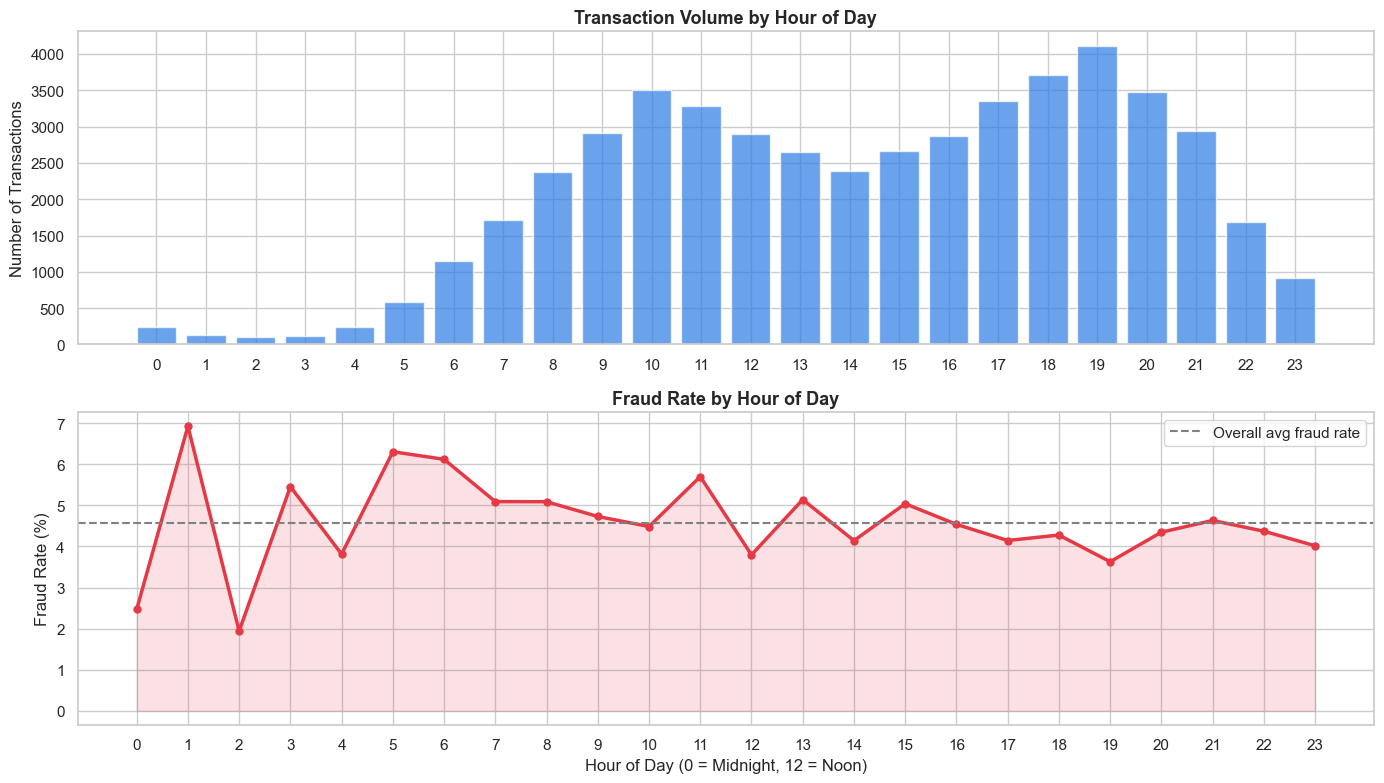

Peak fraud hour : 1:00 (6.92% fraud rate)
Lowest fraud hour: 2:00


In [8]:
df['hour'] = df['timestamp'].dt.hour

hourly = df.groupby('hour').agg(
    total=('is_fraud', 'count'),
    fraud=('is_fraud', 'sum')
).reset_index()
hourly['fraud_rate'] = hourly['fraud'] / hourly['total'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Transaction volume by hour
axes[0].bar(hourly['hour'], hourly['total'], color='#2C7BE5', alpha=0.7)
axes[0].set_title('Transaction Volume by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xticks(range(24))

# Fraud rate by hour
axes[1].plot(hourly['hour'], hourly['fraud_rate'],
             color='#E63946', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(hourly['hour'], hourly['fraud_rate'],
                     alpha=0.15, color='#E63946')
axes[1].axhline(y=df['is_fraud'].mean()*100, color='gray',
                linestyle='--', label='Overall avg fraud rate')
axes[1].set_title('Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
axes[1].set_xticks(range(24))
axes[1].legend()

plt.tight_layout()
plt.show()

peak_fraud_hour = hourly.loc[hourly['fraud_rate'].idxmax(), 'hour']
print(f'Peak fraud hour : {peak_fraud_hour}:00 ({hourly["fraud_rate"].max():.2f}% fraud rate)')
print(f'Lowest fraud hour: {hourly.loc[hourly["fraud_rate"].idxmin(), "hour"]}:00')

## Cell 9 — Day of Week vs Fraud Rate
Do frauds happen more on weekdays or weekends?

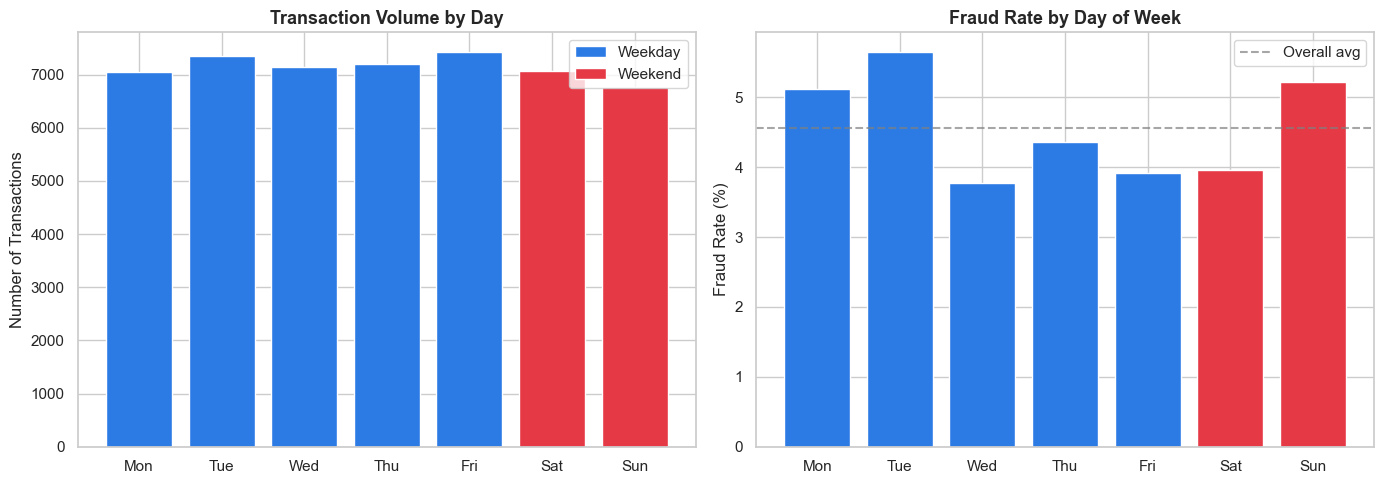

In [9]:
df['day_of_week'] = df['timestamp'].dt.dayofweek
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

daily = df.groupby('day_of_week').agg(
    total=('is_fraud','count'),
    fraud=('is_fraud','sum')
).reset_index()
daily['fraud_rate'] = daily['fraud'] / daily['total'] * 100
daily['day_name'] = daily['day_of_week'].map(dict(enumerate(day_labels)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['#E63946' if i >= 5 else '#2C7BE5' for i in range(7)]

axes[0].bar(daily['day_name'], daily['total'], color=bar_colors, edgecolor='white')
axes[0].set_title('Transaction Volume by Day', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')

axes[1].bar(daily['day_name'], daily['fraud_rate'], color=bar_colors, edgecolor='white')
axes[1].set_title('Fraud Rate by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=df['is_fraud'].mean()*100, color='gray',
                linestyle='--', alpha=0.7, label='Overall avg')
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2C7BE5', label='Weekday'),
                   Patch(facecolor='#E63946', label='Weekend')]
axes[0].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## Cell 10 — Top 10 Most Active Sender Accounts
Which accounts are sending the most transactions? High-frequency senders are suspicious.

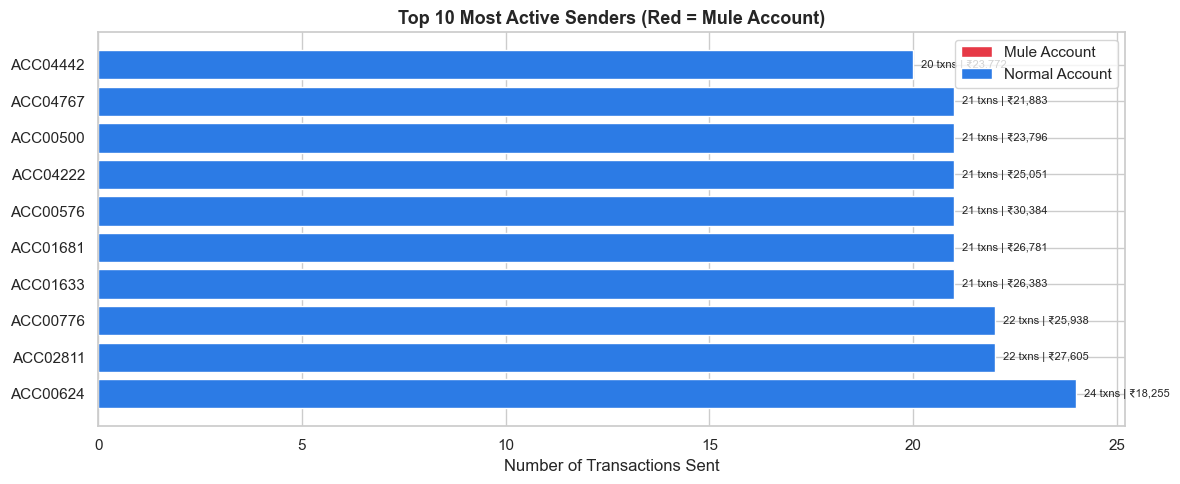

  sender_id  total_txns  total_amount  fraud_txns  is_mule
0  ACC00624          24      18255.08           2    False
1  ACC02811          22      27604.55           2    False
2  ACC00776          22      25938.34           1    False
3  ACC01633          21      26382.74           1    False
4  ACC01681          21      26780.61           1    False
5  ACC00576          21      30383.60           1    False
6  ACC04222          21      25050.81           4    False
7  ACC00500          21      23796.34           3    False
8  ACC04767          21      21882.55           0    False
9  ACC04442          20      23772.20           0    False


In [10]:
top_senders = df.groupby('sender_id').agg(
    total_txns=('txn_id', 'count'),
    total_amount=('amount', 'sum'),
    fraud_txns=('is_fraud', 'sum')
).sort_values('total_txns', ascending=False).head(10).reset_index()

top_senders['is_mule'] = top_senders['sender_id'].isin(
    df_accounts[df_accounts['is_mule']==1]['account_id']
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#E63946' if m else '#2C7BE5' for m in top_senders['is_mule']]
bars = ax.barh(top_senders['sender_id'], top_senders['total_txns'],
               color=colors, edgecolor='white')
ax.set_xlabel('Number of Transactions Sent')
ax.set_title('Top 10 Most Active Senders (Red = Mule Account)',
             fontsize=13, fontweight='bold')
for bar, txns, amount in zip(bars, top_senders['total_txns'],
                              top_senders['total_amount']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{txns} txns | ₹{amount:,.0f}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#E63946', label='Mule Account'),
                   Patch(facecolor='#2C7BE5', label='Normal Account')])
plt.tight_layout()
plt.show()

print(top_senders[['sender_id','total_txns','total_amount','fraud_txns','is_mule']].to_string())

## Cell 11 — Mule vs Normal Account Comparison
How do mule accounts behave differently from normal accounts in terms of transactions received?

=== RECEIVER ACCOUNT COMPARISON ===
                avg_amount_received  total_received  txn_count  fraud_count
Normal Account              1355.32     60925790.56      44953          265
Mule Account                1409.10      7111717.09       5047         2018


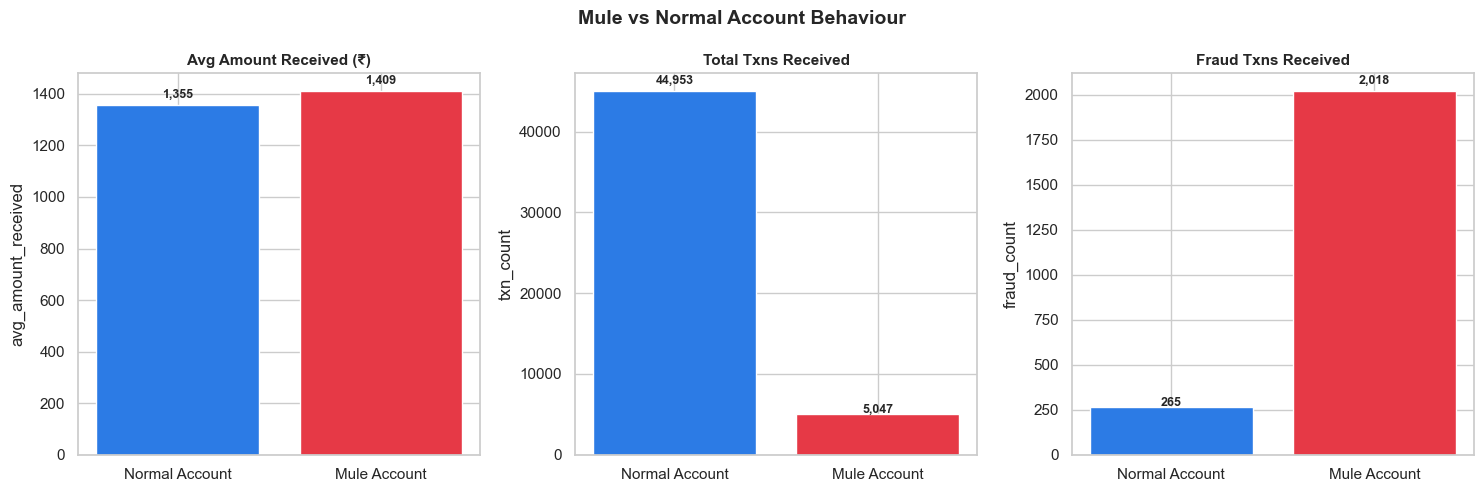

In [11]:
# Merge transactions with account info to get receiver mule status
df_merged = df.merge(
    df_accounts[['account_id','is_mule']].rename(columns={'account_id':'receiver_id'}),
    on='receiver_id', how='left'
)

# Compare received transactions
recv_stats = df_merged.groupby('is_mule').agg(
    avg_amount_received=('amount','mean'),
    total_received=('amount','sum'),
    txn_count=('txn_id','count'),
    fraud_count=('is_fraud','sum')
).round(2)
recv_stats.index = ['Normal Account','Mule Account']

print('=== RECEIVER ACCOUNT COMPARISON ===')
print(recv_stats)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['avg_amount_received', 'txn_count', 'fraud_count']
titles  = ['Avg Amount Received (₹)', 'Total Txns Received', 'Fraud Txns Received']
colors  = ['#2C7BE5','#E63946']

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(recv_stats.index, recv_stats[metric], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    for i, v in enumerate(recv_stats[metric]):
        ax.text(i, v * 1.02, f'{v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Mule vs Normal Account Behaviour', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 12 — Correlation Heatmap
Which numerical features are correlated with each other and with the fraud label?

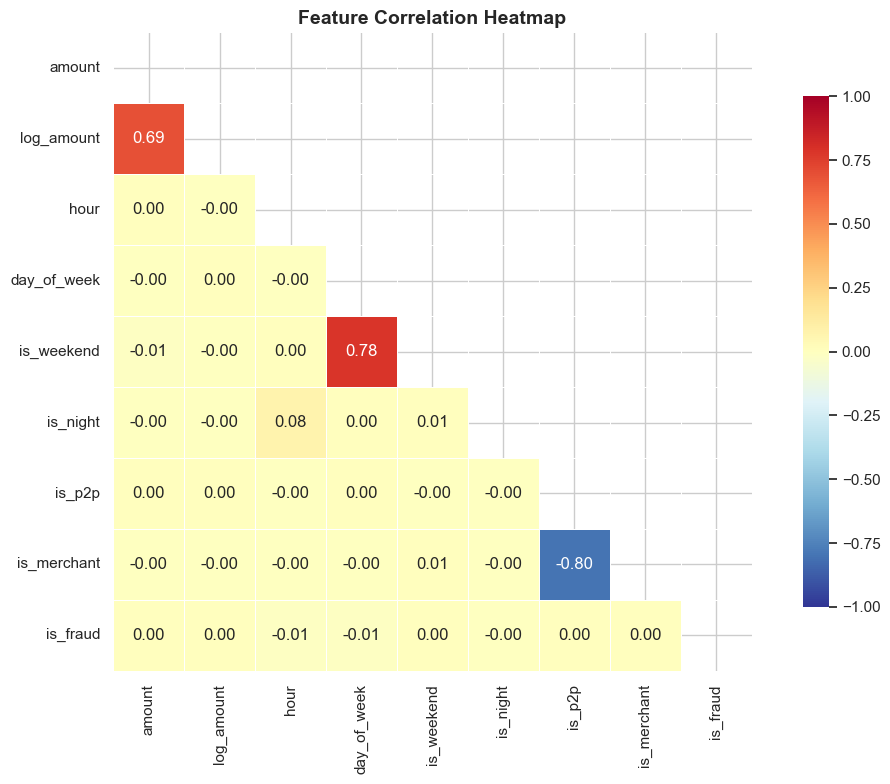

=== CORRELATION WITH is_fraud (sorted) ===
log_amount     0.003392
is_p2p         0.002360
amount         0.001706
is_merchant    0.001080
is_weekend     0.000267
is_night      -0.001300
day_of_week   -0.010613
hour          -0.014757
Name: is_fraud, dtype: float64


In [12]:
# Add numerical features for correlation
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df['log_amount']  = np.log1p(df['amount'])
df['is_p2p']      = (df['txn_type'] == 'P2P').astype(int)
df['is_merchant'] = (df['txn_type'] == 'MERCHANT').astype(int)

corr_cols = ['amount','log_amount','hour','day_of_week',
             'is_weekend','is_night','is_p2p','is_merchant','is_fraud']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== CORRELATION WITH is_fraud (sorted) ===')
print(corr_matrix['is_fraud'].drop('is_fraud').sort_values(ascending=False))

## Cell 13 — UPI Handle Distribution
Which UPI banks are most commonly used in the dataset?

In [15]:
from IPython.display import HTML, display

# Extract UPI handle from VPA (everything after @)
df_accounts['upi_handle'] = df_accounts['vpa'].str.split('@').str[1]

handle_counts = df_accounts['upi_handle'].value_counts()

fig = px.bar(
    x=handle_counts.index,
    y=handle_counts.values,
    labels={'x': 'UPI Handle', 'y': 'Number of Accounts'},
    title='Account Distribution by UPI Handle',
    color=handle_counts.values,
    color_continuous_scale='Blues'
)
fig.update_layout(showlegend=False)
html = fig.to_html(include_plotlyjs='cdn')
display(HTML(html))

print('UPI Handle Distribution:')
print(handle_counts.to_string())

UPI Handle Distribution:
upi_handle
upi           623
ibl           577
okhdfcbank    576
oksbi         568
okaxis        548
ybl           541
paytm         538
kotak         524
okicici       505


## Cell 14 — Summary Insights
Key takeaways from the EDA that guide feature engineering decisions.

In [14]:
print('=' * 55)
print('       EDA SUMMARY — UPI SYNTHETIC DATASET')
print('=' * 55)
print(f'Total transactions    : {len(df):,}')
print(f'Fraud transactions    : {df["is_fraud"].sum():,} ({df["is_fraud"].mean()*100:.2f}%)')
print(f'Avg transaction amt   : ₹{df["amount"].mean():,.0f}')
print(f'Max transaction amt   : ₹{df["amount"].max():,.0f}')
print(f'Total mule accounts   : {df_accounts["is_mule"].sum():,}')
print()
print('KEY INSIGHTS FOR FEATURE ENGINEERING:')
print('-' * 55)
print('1. Class imbalance needs scale_pos_weight in XGBoost')
print('2. Amount distribution is log-normal — use log_amount')
print('3. Hour of day shows fraud pattern — keep as feature')
print('4. Mule accounts show distinct receiver behaviour')
print('5. Velocity features will be critical (SIM-swap pattern)')
print('6. Graph features (PageRank) will catch mule networks')
print('=' * 55)

       EDA SUMMARY — UPI SYNTHETIC DATASET
Total transactions    : 50,000
Fraud transactions    : 2,283 (4.57%)
Avg transaction amt   : ₹1,361
Max transaction amt   : ₹100,000
Total mule accounts   : 500

KEY INSIGHTS FOR FEATURE ENGINEERING:
-------------------------------------------------------
1. Class imbalance needs scale_pos_weight in XGBoost
2. Amount distribution is log-normal — use log_amount
3. Hour of day shows fraud pattern — keep as feature
4. Mule accounts show distinct receiver behaviour
5. Velocity features will be critical (SIM-swap pattern)
6. Graph features (PageRank) will catch mule networks
